In [1]:
# ============================================
# Character-Level LSTM Language Model (PyTorch)
# Google Colab ready (uploads + GPU support)
# Dataset: office_script_clean.txt
# ============================================

import math
import time
import random
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt


In [2]:
# -------------------------------
# 0) Upload dataset (Colab)
# -------------------------------
from google.colab import files
uploaded = files.upload()  # upload office_script_clean.txt

DATA_PATH = "/content/office_script_clean.txt"

Saving office_script_clean.txt to office_script_clean.txt


In [3]:
# -------------------------------
# 1) Reproducibility
# -------------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [4]:
# -------------------------------
# 2) Tokenizer (character-level)
# -------------------------------
class CharTokenizer:
    def __init__(self, text: str):
        chars = sorted(list(set(text)))
        self.vocab = chars
        self.vocab_size = len(chars)
        self.char2id = {c: i for i, c in enumerate(chars)}
        self.id2char = {i: c for i, c in enumerate(chars)}

    def encode(self, s: str):
        return [self.char2id[c] for c in s]

    def decode(self, ids):
        return "".join(self.id2char[i] for i in ids)

In [5]:
# -------------------------------
# 3) Dataset (context window -> next char)
# -------------------------------
class CharWindowDataset(Dataset):
    def __init__(self, encoded_text, context_len: int):
        self.data = torch.tensor(encoded_text, dtype=torch.long)
        self.context_len = context_len
        self.n = len(self.data) - context_len  # each sample needs context_len + 1 chars

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.context_len]        # (T,)
        y = self.data[idx + self.context_len]              # ()
        return x, y



In [6]:
# -------------------------------
# 4) Model: Embedding -> LSTM stack -> Linear
# -------------------------------
class CharLSTM(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=(dropout if num_layers > 1 else 0.0),
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        x: (B, T) token ids
        returns logits for next char (based on last timestep): (B, V)
        """
        emb = self.embedding(x)                # (B, T, E)
        out, hidden = self.lstm(emb, hidden)   # out: (B, T, H)
        last = out[:, -1, :]                   # (B, H)
        logits = self.fc(last)                 # (B, V)
        return logits,hidden


In [7]:
# -------------------------------
# 5) Eval: loss + perplexity
# -------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits, _ = model(x)
        loss = criterion(logits, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_count += bs

    avg_loss = total_loss / max(1, total_count)
    ppl = math.exp(avg_loss)
    return avg_loss, ppl

In [8]:
# -------------------------------
# 6) Train loop (tracks curves)
# -------------------------------
def train(model, train_loader, val_loader, optimizer, criterion, device, epochs: int, grad_clip: float = 1.0):
    history = {"train_loss": [], "train_ppl": [], "val_loss": [], "val_ppl": []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0
        t0 = time.time()

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits, _ = model(x)
            loss = criterion(logits, y)
            loss.backward()

            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            bs = x.size(0)
            total_loss += loss.item() * bs
            total_count += bs

        train_loss = total_loss / max(1, total_count)
        train_ppl = math.exp(train_loss)

        val_loss, val_ppl = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_ppl"].append(train_ppl)
        history["val_loss"].append(val_loss)
        history["val_ppl"].append(val_ppl)

        dt = time.time() - t0
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f}, ppl {train_ppl:.3f} | "
            f"val loss {val_loss:.4f}, ppl {val_ppl:.3f} | "
            f"{dt:.1f}s"
        )

    return history


In [9]:
# -------------------------------
# 7) Plot curves
# -------------------------------
def plot_history(history):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training/Validation Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_ppl"], label="train ppl")
    plt.plot(epochs, history["val_ppl"], label="val ppl")
    plt.xlabel("epoch")
    plt.ylabel("perplexity")
    plt.title("Training/Validation Perplexity")
    plt.legend()
    plt.show()

In [10]:
# -------------------------------
# 8) Generation with temperature
# -------------------------------
@torch.no_grad()
def generate_script(model, tokenizer, seed_text, temperature, num_tokens_to_generate, context_len, device):
    model.eval()

    seed_ids = tokenizer.encode(seed_text)
    generated = list(seed_ids)

    for _ in range(num_tokens_to_generate):
        ctx = generated[-context_len:]
        #if len(ctx) < context_len:
         #   pad_id = ctx[0] if len(ctx) > 0 else 0
          #  ctx = [pad_id] * (context_len - len(ctx)) + ctx

        x = torch.tensor(ctx, dtype=torch.long, device=device).unsqueeze(0)  # (1, T)
        logits, _ = model(x)                                                 # (1, V)
        logits = logits.squeeze(0)

        if temperature <= 0:
            next_id = int(torch.argmax(logits).item())
        else:
            probs = torch.softmax(logits / temperature, dim=-1)
            next_id = int(torch.multinomial(probs, num_samples=1).item())

        generated.append(next_id)

    return tokenizer.decode(generated)

In [11]:
# -------------------------------
# 9) Config
# -------------------------------
@dataclass
class Config:
    data_path: str = DATA_PATH
    context_len: int = 120

    batch_size: int = 256
    epochs: int = 5
    lr: float = 2e-3

    embed_dim: int = 64
    hidden_dim: int = 256
    num_layers: int = 2
    dropout: float = 0.2

    grad_clip: float = 1.0
    num_workers: int = 2



In [12]:
# -------------------------------
# 10) Run everything
# -------------------------------
def main():
    set_seed(42)
    cfg = Config()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # Load dataset
    with open(cfg.data_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Normalize newlines (safe)
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # -------------------------------
    # Leak-free splits (IMPORTANT)
    # -------------------------------
    # 1) Split the raw TEXT first (contiguous), then fit tokenizer on TRAIN ONLY.
    #    This avoids "vocab peeking" into test.
    split_char = int(0.9 * len(text))
    train_text = text[:split_char]
    test_text = text[split_char:]

    # Tokenizer fit ONLY on training text (strict)
    tokenizer = CharTokenizer(train_text)

    train_ids = tokenizer.encode(train_text)
    test_ids = tokenizer.encode(test_text)

    # 2) Build validation as a CONTIGUOUS chunk from training text.
    #    This avoids leakage that happens when randomly splitting overlapping windows.
    val_frac = 0.05
    val_start = int((1 - val_frac) * len(train_ids))
    train_ids2 = train_ids[:val_start]
    val_ids2 = train_ids[val_start:]

    # Datasets (window -> next char)
    train_ds = CharWindowDataset(train_ids2, cfg.context_len)
    val_ds = CharWindowDataset(val_ids2, cfg.context_len)
    test_ds = CharWindowDataset(test_ids, cfg.context_len)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    # Required data stats
    print("\n--- Data stats (must show) ---")
    print("Total characters used:", len(text))
    print("Train chars:", len(train_text), "| Val chars:", len(val_ids2), "| Test chars:", len(test_text))
    print("Vocab size (train-only):", tokenizer.vocab_size)
    print("Context length:", cfg.context_len)

    # Model
    model = CharLSTM(
        vocab_size=tokenizer.vocab_size,
        embed_dim=cfg.embed_dim,
        hidden_dim=cfg.hidden_dim,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr)

    # Train
    history = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=cfg.epochs,
        grad_clip=cfg.grad_clip,
    )

    # Curves (loss + perplexity)
    plot_history(history)

    # Holdout test perplexity
    test_loss, test_ppl = evaluate(model, test_loader, criterion, device)
    print("\n--- Holdout test set (last 10% of text) ---")
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test perplexity: {test_ppl:.3f}")

    # Generation: at least 3 temps
    seed_text = "MICHAEL: "
    temps = [0.3, 0.7, 1.0]

    print("\n--- Generation samples (must show) ---")
    for t in temps:
        sample = generate_script(
            model=model,
            tokenizer=tokenizer,
            seed_text=seed_text,
            temperature=t,
            num_tokens_to_generate=600,
            context_len=cfg.context_len,
            device=device,
        )
        print(f"\n[Temperature = {t}]")
        print(sample)


Device: cuda

--- Data stats (must show) ---
Total characters used: 3427466
Train chars: 3084719 | Val chars: 154236 | Test chars: 342747
Vocab size (train-only): 72
Context length: 120
Epoch 01/5 | train loss 1.4072, ppl 4.084 | val loss 1.3697, ppl 3.934 | 840.7s
Epoch 02/5 | train loss 1.2558, ppl 3.511 | val loss 1.3210, ppl 3.747 | 839.1s
Epoch 03/5 | train loss 1.2217, ppl 3.393 | val loss 1.2969, ppl 3.658 | 837.9s
Epoch 04/5 | train loss 1.2015, ppl 3.325 | val loss 1.2853, ppl 3.616 | 840.0s
Epoch 05/5 | train loss 1.1884, ppl 3.282 | val loss 1.2758, ppl 3.582 | 840.4s


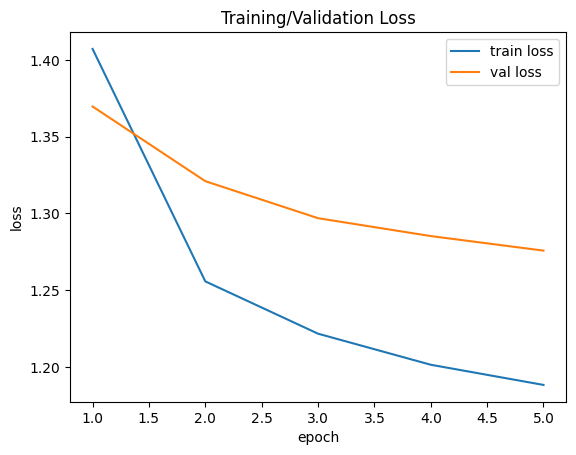

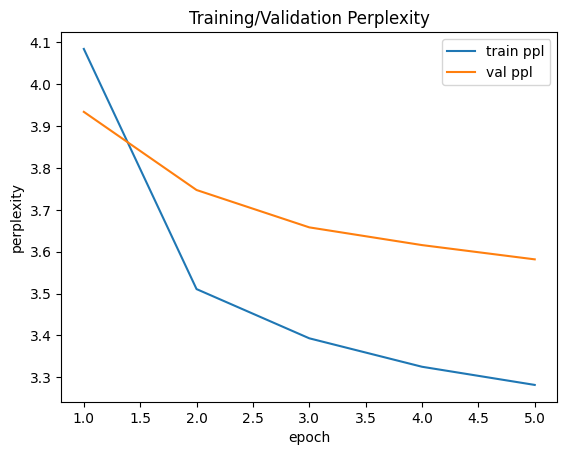


--- Holdout test set (last 10% of text) ---
Test loss: 1.2678
Test perplexity: 3.553

--- Generation samples (must show) ---

[Temperature = 0.3]
MICHAEL: Okay, I was just so sorry.
Pam: Okay, I don't know what you want to be a lot of times and I want to see this poster to the stupid party and I don't think I was going to go to my course with you thing to see the trip of the same things and I can stay at the love to me. I don't know what I think you can do this.
Ryan: I just wanted to get the second stuff and I always wanted to be a boyfriend to see you guys around the business or the party and I was like the same with the last night. I don't want to be a big problem. I don't know that I don't know that I think I don't know what the top of the w

[Temperature = 0.7]
MICHAEL: God!
Ryan: No, I'm talking about to make this to the only enough and she's fine, but I can prove my destination problem. And that's a lot of tacks. And I'm fine. I was wanted to see what I might be about for peopl

In [13]:
main()